Rodolfo Del Castillo Wilches y Julieta Madrigal Flores

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [ ]:
# Parámetros

S0 = 670
K = 680
r = 0.04
sigma = 0.17
N = 30          # numero de días
T = N/365       # tiempo al venc.
M = 10000       # numero de simulaciones
dt = T/N

Z = np.random.standard_normal((M,N))

retornos = (r - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * Z

S_paths = S0 * np.exp(np.cumsum(retornos, axis = 1))
S_paths = np.insert(S_paths, 0, S0, axis = 1)

# vector de precios al vencimiento
ST = S_paths[:,-1]
# vector de precios promedio de fluctuacion del subyacente
S_media = S_paths.mean(axis=1)

europea = np.exp(-r * T) * np.maximum(ST - K, 0)
asiatica = np.exp(-r * T) * np.maximum(S_media - K, 0)

# analítica Black Scholes
d1 = (np.log(S0 / K) + (r + 0.5 * sigma **2) * T / sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)
bs_call = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

print("Precio Asiatica:",asiatica.mean())
print("Precio Europea:",europea.mean())
print("Precio Black Scholes:",bs_call)


Precio Asiatica: 3.8111963518463163
Precio Europea: 9.429621969489919
Precio Black Scholes: 9.308744964731545


### Grafica:

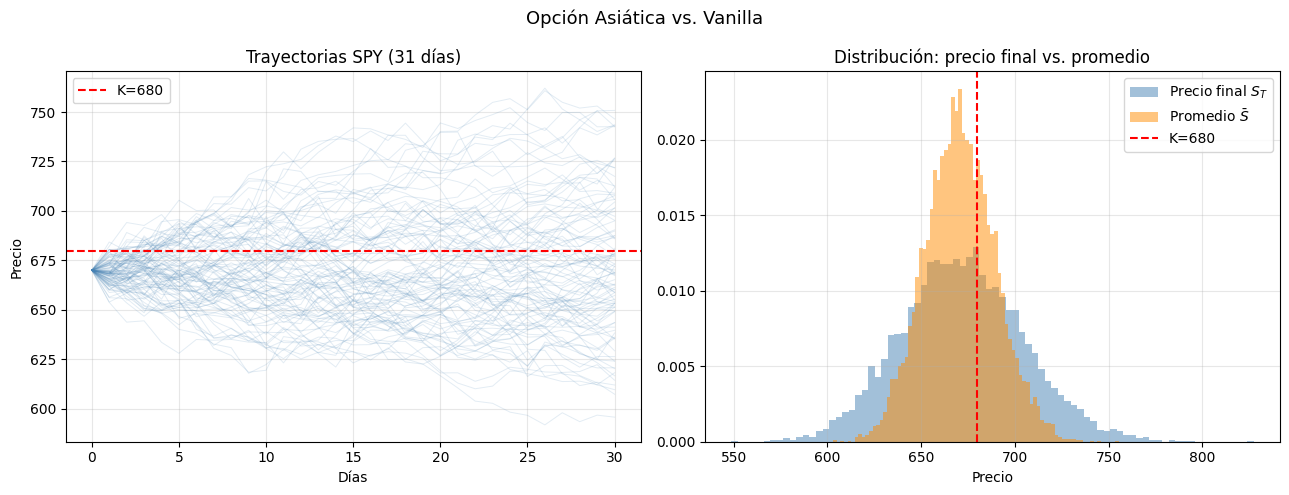

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Trayectorias con el promedio marcado
for i in range(100):
    axes[0].plot(S_paths[i], alpha=0.15, linewidth=0.7, color='steelblue')
axes[0].axhline(K, color='red', linestyle='--', linewidth=1.5, label=f'K={K}')
axes[0].set_title('Trayectorias SPY (31 días)')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Precio')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribución: precio final vs. promedio
axes[1].hist(ST,      bins=80, density=True, alpha=0.5,
             color='steelblue', label='Precio final $S_T$')
axes[1].hist(S_media, bins=80, density=True, alpha=0.5,
             color='darkorange', label='Promedio $\\bar{S}$')
axes[1].axvline(K, color='red', linestyle='--', label=f'K={K}')
axes[1].set_title('Distribución: precio final vs. promedio')
axes[1].set_xlabel('Precio')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Opción Asiática vs. Vanilla', fontsize=13)
plt.tight_layout()
plt.show()

### Opciones con Barrera:

In [ ]:
B_up = 710

S_max = S_paths.max(axis=1)


# up and out
activa_up_and_out = (S_max < B_up)
call_up_and_out = np.exp(-r * T) * np.maximum(ST - K, 0) * activa_up_and_out

# up and out
activa_up_and_in = (S_max > B_up)
call_up_and_in = np.exp(-r * T) * np.maximum(ST - K, 0) * activa_up_and_in

print("up and out: ", call_up_and_out.mean())
print("up and in: ", call_up_and_in.mean())
print("europea", europea.mean())
print("comprobacion", call_up_and_out.mean() + call_up_and_in.mean()  )

up and out:  2.290203711647812
up and in:  7.139418257842107
europea 9.429621969489919
comprobacion 9.429621969489919


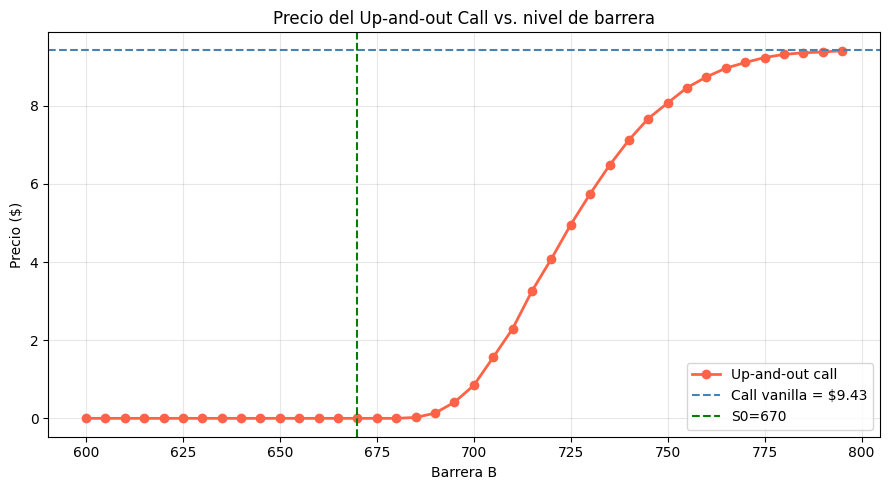

In [ ]:
B_range = np.arange(600, 800, 5)   # barreras superiores
precios_uao = []

for b in B_range:
    s_max_b = S_paths.max(axis=1)
    precio  = np.exp(-r*T) * np.maximum(ST - K, 0) * (s_max_b < b)
    precios_uao.append(precio.mean())

plt.figure(figsize=(9, 5))
plt.plot(B_range, precios_uao, color='tomato', linewidth=2, marker='o',
         label='Up-and-out call')
plt.axhline(europea.mean(), color='steelblue', linestyle='--',
            linewidth=1.5, label=f'Call vanilla = ${europea.mean():.2f}')
plt.axvline(S0, color='green', linestyle='--', label=f'S0={S0}')
plt.xlabel('Barrera B')
plt.ylabel('Precio ($)')
plt.title('Precio del Up-and-out Call vs. nivel de barrera')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- La opción asiática es más barata que la vanilla. ¿Siempre es así? ¿Puedes pensar en algún caso donde fueran igual de caras?

No siempre, pero casi siempre la asiática es más barata porque promedia el precio cambia a menor volatilidad efectiva igual menor valor.


Podría valer si el promedio ≈ precio final
En el límite, si la asiática se define con un solo fixing, se vuelve equivalente a una vanilla.



- Verificaste que up-and-in + up-and-out = vanilla. ¿Qué implica eso para el pricing? ¿Puedes usarlo para encontrar el precio de una si conoces la otra?

Esto implica una descomposición:

La opción vanilla se puede replicar con estas dos.
Entonces:
Precio vanilla = precio up-in + precio up-out

Sí se puede usar para pricing:

Si conoces vanilla y up-and-out → sacas up-and-in
Si conoces vanilla y up-and-in → sacas up-and-out

Es básicamente arbitraje / replicación.




- Si la barrera B está muy cerca de S0, el up-and-out call casi no vale nada. ¿Por qué? ¿Y si la barrera está muy lejos?

Barrera muy cerca de S₀ es el up-and-out casi no vale porque es muy probable que toque la barrera dado que se “mata” la opción rápido.
Barrera muy lejos es poco probable que se toque la opción se comporta casi como una vanilla igual en valor alto.



- ¿Por qué Monte Carlo es especialmente apropiado para opciones exóticas? ¿Cuál es su limitación principal vs. soluciones analíticas?

Es ideal porque no necesitas fórmula cerrada y puedes simular trayectorias complejas

Limitación principal:

Es lento debido a la convergencia ∝ 1/√N, mucho ruido lo que necesita muchas simulaciones para precisión y comparado con soluciones analíticas es menos eficiente y menos exacto